In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Basic Metrics

In [59]:
df["openReturn"] = df["Open"].pct_change()
df["highReturn"] = df["High"].pct_change()
df["lowReturn"] = df["Low"].pct_change()
df["closeReturn"] = df["Close"].pct_change() ## Same as "Daily Return"
df["volumeChange"] = df["Volume"].pct_change()

In [60]:
df["target_return"] = df["Close"].pct_change()

## 补充feature
### 1.价格结构类
$$\text{Gap}_t=\frac{Open_t-Close_{t-1}}{Close_{t-1}}$$
含义：  
overnight information  
news / sentiment

Intraday return
$$\text{Intra}_t=\frac{Close_t-Open_t}{Open_t}$$
含义：  
当天交易行为  

High-Low range
$$\text{Range}_t=\frac{High_t-Low_t}{Close_{t-1}}$$
volatility proxy

In [61]:
# 1. Gap
df["gap"] = (df["Open"] - df["Close"].shift(1)) / df["Close"].shift(1)

# 2. Intraday Return
df["intraday_return"] = (df["Close"] - df["Open"]) / df["Open"]

# 3. High-Low Range
df["high_low_range"] = (df["High"] - df["Low"]) / df["Close"].shift(1)

# 4. Upward and downward pressure
df["high_return_from_prev_close"] = (df["High"] - df["Close"].shift(1)) / df["Close"].shift(1)
df["low_return_from_prev_close"] = (df["Low"] - df["Close"].shift(1)) / df["Close"].shift(1)

### 2.时间结构

In [62]:
# Lag return
df["return_lag1"] = df["target_return"].shift(1)
df["return_lag2"] = df["target_return"].shift(2)
df["return_lag3"] = df["target_return"].shift(3)
df["return_lag5"] = df["target_return"].shift(5)
df["return_lag10"] = df["target_return"].shift(10)

k lag return:$$R_{t-k}$$

In [63]:
# Rolling mean of past returns
df["rolling_mean_5"] = df["target_return"].shift(1).rolling(window=5).mean()
df["rolling_mean_10"] = df["target_return"].shift(1).rolling(window=10).mean()
df["rolling_mean_20"] = df["target_return"].shift(1).rolling(window=20).mean()

# Rolling volatility of past returns
df["rolling_vol_5"] = df["target_return"].shift(1).rolling(window=5).std()
df["rolling_vol_10"] = df["target_return"].shift(1).rolling(window=10).std()
df["rolling_vol_20"] = df["target_return"].shift(1).rolling(window=20).std()

# Rolling max and min return
df["rolling_max_5"] = df["target_return"].shift(1).rolling(window=5).max()
df["rolling_min_5"] = df["target_return"].shift(1).rolling(window=5).min()

# Momentum-type feature
df["momentum_5"] = df["Close"].pct_change(periods=5).shift(1)
df["momentum_10"] = df["Close"].pct_change(periods=10).shift(1)

### 3.非线性结构

In [64]:
# Squared return as volatility proxy
df["squared_return_lag1"] = df["return_lag1"] ** 2
df["squared_return_lag2"] = df["return_lag2"] ** 2

# Absolute return as another volatility proxy
df["abs_return_lag1"] = df["return_lag1"].abs()
df["abs_return_lag2"] = df["return_lag2"].abs()

# Squared gap
df["gap_squared"] = df["gap"] ** 2

# Interaction terms
df["gap_x_vol5"] = df["gap"] * df["rolling_vol_5"]
df["gap_x_momentum5"] = df["gap"] * df["momentum_5"]
df["vol5_x_momentum5"] = df["rolling_vol_5"] * df["momentum_5"]

# Range interaction
df["range_x_vol5"] = df["high_low_range"] * df["rolling_vol_5"]

### 4. Market Behavior Features（市场行为特征）

第四层主要围绕 **Volume（成交量）** 构造特征。虽然在 EDA 的相关性矩阵中，`volumeChange` 与价格变化的线性相关性不强，但这并不代表 Volume 没有信息。

Volume 更多反映的是：

- 市场交易活跃度；
- 市场流动性；
- 投资者参与程度；
- 异常交易行为；
- 信息冲击下的市场反应强度。

因此，第四层的核心思想不是直接把原始 `Volume` 放进模型，而是把成交量转化成更有解释力的市场行为特征。

---

#### 4.1 Log Volume

原始成交量通常数值很大，并且容易受到极端值影响。例如在金融危机、疫情冲击或重大新闻发布期间，成交量可能突然放大很多倍。

如果直接使用原始 `Volume`，可能会导致模型受到尺度影响，尤其是对于 Linear Regression、KNN、PCA 这类对变量尺度敏感的模型。

因此，我们对成交量进行对数变换：

$$
\text{LogVolume}_t = \log(1 + Volume_t)
$$

其中加入 1 是为了避免当成交量为 0 时无法取对数。

这个特征的作用是压缩成交量的尺度，降低极端值的影响，使成交量信息更稳定地进入模型。

---

#### 4.2 Lagged Volume Change

成交量变化可以反映市场交易活跃度的变化，但如果直接使用当天成交量变化，可能会引入当天信息。因此，我们使用上一期成交量变化作为特征。

定义为：

$$
\text{VolumeChangeLag1}_t =
\frac{Volume_{t-1} - Volume_{t-2}}{Volume_{t-2}}
$$

这个变量表示前一交易日成交量相对于再前一交易日的变化比例。

如果该值较大，说明上一交易日市场交易活跃度明显上升；如果该值较小或为负，说明市场交易活跃度下降。

该特征可以帮助模型捕捉成交量变化是否会对后续收益率产生影响。

---

#### 4.3 Rolling Average Volume

单日成交量本身很难判断是否异常，因此需要构造一个历史基准。这里使用过去一段时间的平均成交量作为参考水平。

例如，过去 20 天的平均成交量可以表示为：

$$
\text{VolumeMA20}_t =
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

注意这里使用的是从 \(t-1\) 到 \(t-20\) 的历史成交量，而不是包含当天 \(t\) 的成交量。

这样做的原因是避免 look-ahead bias，也就是避免模型使用当天尚未完全发生的信息。

这个变量的作用是衡量近期正常成交量水平，为后续判断成交量是否异常提供基准。

---

#### 4.4 Volume Ratio

Volume Ratio 用来衡量当天成交量相对于过去平均成交量的强弱。

定义为：

$$
\text{VolumeRatio20}_t =
\frac{Volume_t}{\text{VolumeMA20}_t}
$$

其中：

$$
\text{VolumeMA20}_t =
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

如果：

$$
\text{VolumeRatio20}_t > 1
$$

说明当天成交量高于过去 20 天平均水平。

如果：

$$
\text{VolumeRatio20}_t \gg 1
$$

说明当天成交量异常放大，可能对应市场中出现重大信息冲击，例如金融危机、疫情、政策变化、财报事件或投资者恐慌性交易。

相比原始 `Volume`，`volume_ratio_20` 更有解释力，因为它不是看成交量的绝对大小，而是看成交量相对于近期历史水平是否异常。

---

#### 4.5 Volume Spike Dummy

为了更直接地捕捉异常成交量，我们可以构造一个二元变量，即 Volume Spike Dummy。

定义为：

$$
\text{VolumeSpike}_t =
\begin{cases}
1, & \text{if } \text{VolumeRatio20}_t > 1.5 \\
0, & \text{otherwise}
\end{cases}
$$

其中阈值 1.5 表示当天成交量超过过去 20 天平均成交量的 1.5 倍。

如果：

$$
\text{VolumeSpike}_t = 1
$$

说明当天市场交易活动明显高于正常水平，可能代表市场受到新闻、危机、政策或其他重大事件影响。

如果：

$$
\text{VolumeSpike}_t = 0
$$

说明当天成交量没有明显异常。

这个变量的优点是解释性很强，模型可以直接识别“是否发生异常成交量冲击”。

---

#### 4.6 Volume Z-score

Volume Z-score 用标准化的方式衡量当前成交量相对于历史成交量的异常程度。

定义为：

$$
\text{VolumeZScore20}_t =
\frac{
Volume_t - \mu_{Volume,t-1:t-20}
}{
\sigma_{Volume,t-1:t-20}
}
$$

其中：

$$
\mu_{Volume,t-1:t-20}
=
\frac{1}{20}
\sum_{i=1}^{20} Volume_{t-i}
$$

表示过去 20 天成交量均值。

$$
\sigma_{Volume,t-1:t-20}
$$

表示过去 20 天成交量标准差。

如果：

$$
\text{VolumeZScore20}_t > 0
$$

说明当天成交量高于过去 20 天平均水平。

如果：

$$
\text{VolumeZScore20}_t \gg 0
$$

说明当天成交量显著异常放大。

如果：

$$
\text{VolumeZScore20}_t < 0
$$

说明当天成交量低于近期平均水平。

相比 `volume_ratio_20`，`volume_zscore_20` 不仅考虑成交量是否高于平均水平，还考虑了历史成交量自身的波动程度，因此可以更标准化地衡量异常程度。

---

#### 4.7 Price-Volume Interaction

在 EDA 中，`volumeChange` 与价格变化的线性相关性不强，但这并不说明成交量没有用。

成交量可能不是直接影响收益率，而是会放大某些价格信号。例如，同样是开盘跳空，如果成交量很低，可能只是短暂噪声；但如果成交量同时显著放大，则说明市场中有更多投资者参与，这个价格信号可能更重要。

因此，我们构造价格与成交量的交互项。

---

##### 4.7.1 Volume × Gap

开盘跳空 Gap 定义为：

$$
\text{Gap}_t =
\frac{Open_t - Close_{t-1}}{Close_{t-1}}
$$

Volume Ratio 定义为：

$$
\text{VolumeRatio20}_t =
\frac{Volume_t}{\text{VolumeMA20}_t}
$$

二者的交互项为：

$$
\text{VolumeGapInteraction}_t =
\text{VolumeRatio20}_t \times \text{Gap}_t
$$

这个变量表示：当成交量异常放大时，开盘跳空信号是否更强。

如果 Gap 很大，并且 Volume Ratio 也很大，那么说明市场不仅出现了价格跳空，同时也有大量交易参与，这可能代表更强的信息冲击。

---

##### 4.7.2 Volume × Absolute Lagged Return

为了衡量成交量是否会放大前一日市场波动的影响，可以构造：

$$
\text{VolumeAbsReturnInteraction}_t =
\text{VolumeRatio20}_t \times |R_{t-1}|
$$

其中：

$$
|R_{t-1}|
$$

表示上一交易日收益率的绝对值，用来衡量上一交易日波动大小。

如果上一交易日波动很大，并且当天成交量也很高，那么市场可能仍然处于高关注度或高不确定性状态。

这个变量可以帮助模型捕捉 volatility clustering 和 market attention 的共同作用。

In [65]:
# Log volume: reduce scale problem
df["log_volume"] = np.log1p(df["Volume"])

# Lagged volume change
df["volume_change_lag1"] = df["Volume"].pct_change().shift(1)

# Rolling average volume
df["volume_ma_5"] = df["Volume"].shift(1).rolling(window=5).mean()
df["volume_ma_20"] = df["Volume"].shift(1).rolling(window=20).mean()

# Volume ratio: current volume compared with previous 20-day average
df["volume_ratio_20"] = df["Volume"] / df["volume_ma_20"]

# Volume spike dummy
df["volume_spike"] = (df["volume_ratio_20"] > 1.5).astype(int)

# Volume z-score
df["volume_zscore_20"] = (
    (df["Volume"] - df["Volume"].shift(1).rolling(window=20).mean())
    / df["Volume"].shift(1).rolling(window=20).std()
)

# Price-volume interaction
df["volume_x_gap"] = df["volume_ratio_20"] * df["gap"]
df["volume_x_abs_return_lag1"] = df["volume_ratio_20"] * df["abs_return_lag1"]

### 5.事件信息
采用Crisis dummy

In [66]:
df["crisis_dummy"] = 0

# 1987 Black Monday
df.loc[
    (df["Date"] >= "1987-10-01") & (df["Date"] <= "1987-12-31"),
    "crisis_dummy"
] = 1

# 2000-2003 Dot-com bubble, 9/11, corporate scandals
df.loc[
    (df["Date"] >= "2000-01-01") & (df["Date"] <= "2003-12-31"),
    "crisis_dummy"
] = 1

# 2007-2009 Global Financial Crisis
df.loc[
    (df["Date"] >= "2007-01-01") & (df["Date"] <= "2009-12-31"),
    "crisis_dummy"
] = 1

# 2019-2020 COVID period
df.loc[
    (df["Date"] >= "2019-12-01") & (df["Date"] <= "2020-12-31"),
    "crisis_dummy"
] = 1


# Separate crisis indicators if you want the model to distinguish different crises
df["black_monday_1987"] = (
    (df["Date"] >= "1987-10-01") & (df["Date"] <= "1987-12-31")
).astype(int)

df["dotcom_2000_2003"] = (
    (df["Date"] >= "2000-01-01") & (df["Date"] <= "2003-12-31")
).astype(int)

df["gfc_2007_2009"] = (
    (df["Date"] >= "2007-01-01") & (df["Date"] <= "2009-12-31")
).astype(int)

df["covid_2019_2020"] = (
    (df["Date"] >= "2019-12-01") & (df["Date"] <= "2020-12-31")
).astype(int)


In [67]:
# ============================================================
# Calendar Features
# 这些不是必须，但对传统模型有时有帮助
# ============================================================

df["day_of_week"] = df["Date"].dt.dayofweek
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

# One-hot encoding for weekday and month
df = pd.get_dummies(df, columns=["day_of_week", "month"], drop_first=True)

In [68]:
# ============================================================
# Clean infinite values and missing values
# ============================================================

df = df.replace([np.inf, -np.inf], np.nan)

# drop rows created by pct_change, rolling, shift
df_model = df.dropna().reset_index(drop=True)

print(df_model.shape)
df_model.head()

(16010, 71)


,Date,Open,High,Low,Close,Volume,openReturn,highReturn,lowReturn,closeReturn,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,1957-04-02,44.419998,44.419998,44.419998,44.419998,2300000,0.006343,0.006343,0.006343,0.006343,...,False,True,False,False,False,False,False,False,False,False
1,1957-04-03,44.540001,44.540001,44.540001,44.540001,2160000,0.002702,0.002702,0.002702,0.002702,...,False,True,False,False,False,False,False,False,False,False
2,1957-04-04,44.439999,44.439999,44.439999,44.439999,1820000,-0.002245,-0.002245,-0.002245,-0.002245,...,False,True,False,False,False,False,False,False,False,False
3,1957-04-05,44.490002,44.490002,44.490002,44.490002,1830000,0.001125,0.001125,0.001125,0.001125,...,False,True,False,False,False,False,False,False,False,False
4,1957-04-08,44.389999,44.389999,44.389999,44.389999,1950000,-0.002248,-0.002248,-0.002248,-0.002248,...,False,True,False,False,False,False,False,False,False,False


# Feature Classify

In [69]:
# predictive features
predictive_features = [
    # gap known at market open
    "gap",

    # lagged return features
    "return_lag1",
    "return_lag2",
    "return_lag3",
    "return_lag5",
    "return_lag10",

    # rolling trend and volatility
    "rolling_mean_5",
    "rolling_mean_10",
    "rolling_mean_20",
    "rolling_vol_5",
    "rolling_vol_10",
    "rolling_vol_20",
    "rolling_max_5",
    "rolling_min_5",

    # momentum
    "momentum_5",
    "momentum_10",

    # nonlinear lagged risk features
    "squared_return_lag1",
    "squared_return_lag2",
    "abs_return_lag1",
    "abs_return_lag2",
    "gap_squared",
    "gap_x_vol5",
    "gap_x_momentum5",
    "vol5_x_momentum5",

    # volume features
    "log_volume",
    "volume_change_lag1",
    "volume_ratio_20",
    "volume_spike",
    "volume_zscore_20",
    "volume_x_gap",
    "volume_x_abs_return_lag1",

    # crisis features
    "crisis_dummy",
    "black_monday_1987",
    "dotcom_2000_2003",
    "gfc_2007_2009",
    "covid_2019_2020"
]

# add dummy columns automatically
dummy_cols = [col for col in df_model.columns if col.startswith("day_of_week_") or col.startswith("month_")]
predictive_features = predictive_features + dummy_cols

X_predictive = df_model[predictive_features]
y = df_model["target_return"]

print(X_predictive.shape, y.shape)

(16010, 51) (16010,)


In [70]:
# explainatory_features
explanatory_features = predictive_features + [
    "intraday_return",
    "high_low_range",
    "high_return_from_prev_close",
    "low_return_from_prev_close",
    "range_x_vol5"
]

X_explanatory = df_model[explanatory_features]
y = df_model["target_return"]

print(X_explanatory.shape, y.shape)

(16010, 56) (16010,)


# Target: continuous daily return
Feature Engineering  
        ↓  
Train/Test split by time  
        ↓  
StandardScaler  
        ↓  
├── Linear Regression  
├── Ridge Regression  
├── Lasso Regression  
├── Polynomial Regression  
├── kNN Regression  
└── PCA + Linear Regression

In [71]:
# ============================================================
# Choose feature set
# ============================================================

# For strict prediction, use predictive features
X = X_predictive.copy()
feature_names = predictive_features.copy()

# If you want explanatory analysis instead, use this:
# X = X_explanatory.copy()
# feature_names = explanatory_features.copy()

y = df_model["target_return"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape) 

X shape: (16010, 51)
y shape: (16010,)


In [72]:
# ============================================================
# Train/Test split by time
# ============================================================

split_ratio = 0.8
split_index = int(len(df_model) * split_ratio)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

date_train = df_model["Date"].iloc[:split_index]
date_test = df_model["Date"].iloc[split_index:]

print("Train period:", date_train.min(), "to", date_train.max())
print("Test period:", date_test.min(), "to", date_test.max())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Train period: 1957-04-02 00:00:00 to 2008-02-19 00:00:00
Test period: 2008-02-20 00:00:00 to 2020-11-04 00:00:00
X_train shape: (12808, 51)
X_test shape: (3202, 51)


In [73]:
# ============================================================
# Build model pipelines
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.0001, max_iter=10000))
    ]),

    "Polynomial Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", Ridge(alpha=1.0))
    ]),

    "kNN Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=10))
    ]),

    "PCA + Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", LinearRegression())
    ])
}

In [74]:
# ============================================================
# Train and evaluate all models
# ============================================================

results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Directional accuracy: whether predicted sign matches actual sign
    direction_acc = np.mean(np.sign(y_pred) == np.sign(y_test))

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": direction_acc
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MSE,RMSE,MAE,R2,Directional Accuracy
0,Lasso Regression,0.000142,0.011899,0.007362,0.205336,0.640849
1,Linear Regression,0.000152,0.012330,0.007529,0.146709,0.628357
2,Ridge Regression,0.000153,0.012363,0.007532,0.142239,0.628670
3,kNN Regression,0.000155,0.012460,0.008041,0.128643,0.539350
4,PCA + Linear Regression,0.000161,0.012688,0.007482,0.096469,0.636477
5,Polynomial Regression,0.045663,0.213689,0.023881,-255.271677,0.617739


In [75]:
# ============================================================
# Best model by RMSE
# ============================================================

best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)
results_df.head()

Best model: Lasso Regression


,Model,MSE,RMSE,MAE,R2,Directional Accuracy
0,Lasso Regression,0.000142,0.011899,0.007362,0.205336,0.640849
1,Linear Regression,0.000152,0.012330,0.007529,0.146709,0.628357
2,Ridge Regression,0.000153,0.012363,0.007532,0.142239,0.628670
3,kNN Regression,0.000155,0.012460,0.008041,0.128643,0.539350
4,PCA + Linear Regression,0.000161,0.012688,0.007482,0.096469,0.636477


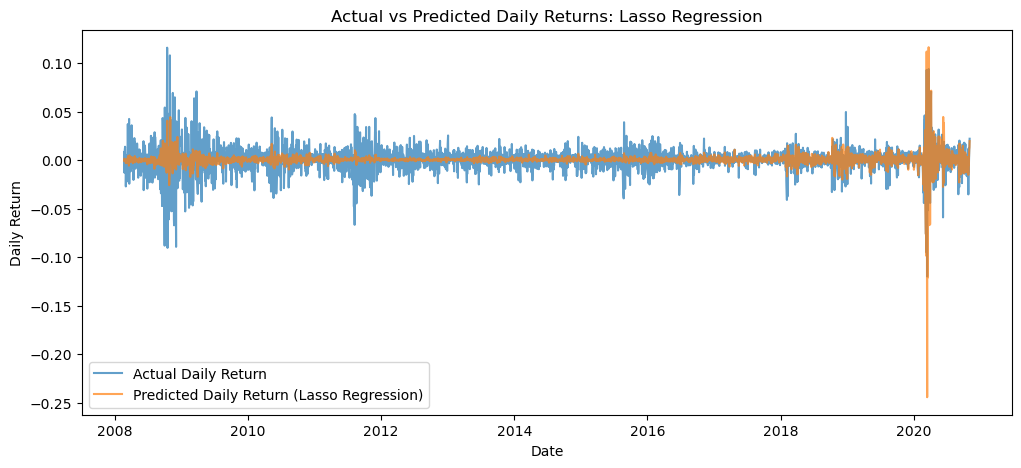

In [76]:
# ============================================================
# Plot actual vs predicted returns
# ============================================================

import matplotlib.pyplot as plt

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.plot(date_test, y_test.values, label="Actual Daily Return", alpha=0.7)
plt.plot(date_test, y_pred_best, label=f"Predicted Daily Return ({best_model_name})", alpha=0.7)

plt.title(f"Actual vs Predicted Daily Returns: {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.show()

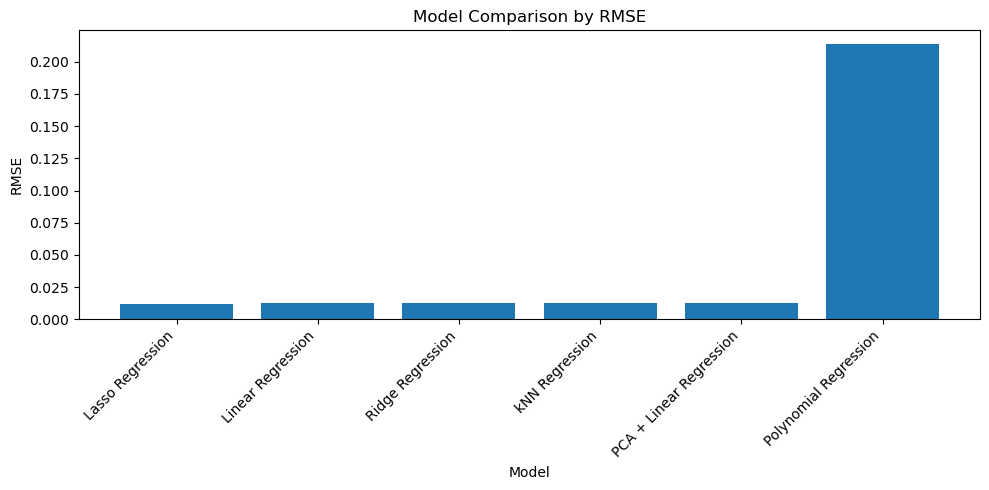

In [77]:
# ============================================================
# Compare RMSE across models
# ============================================================

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

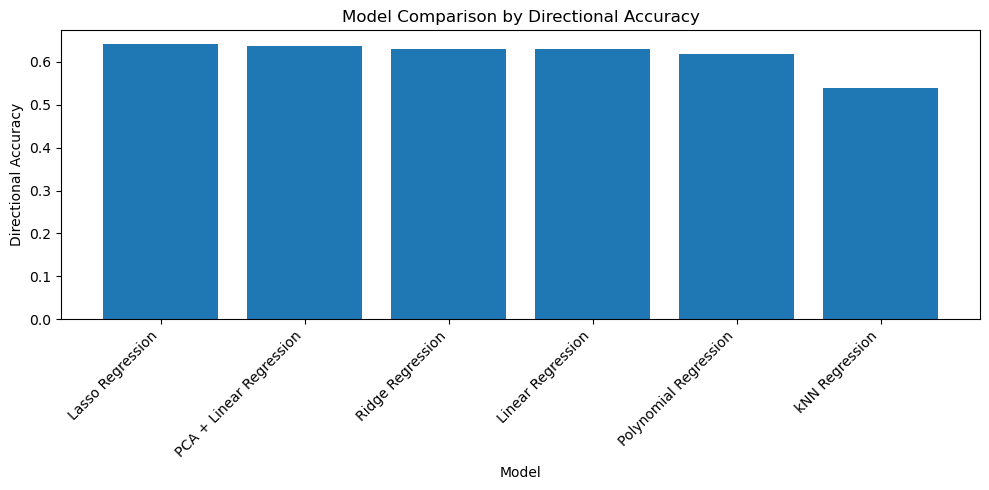

In [78]:
# ============================================================
# Compare directional accuracy across models
# ============================================================

direction_df = results_df.sort_values("Directional Accuracy", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(direction_df["Model"], direction_df["Directional Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by Directional Accuracy")
plt.xlabel("Model")
plt.ylabel("Directional Accuracy")
plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# Lasso feature importance
# ============================================================

lasso_pipeline = models["Lasso Regression"]
lasso_pipeline.fit(X_train, y_train)

lasso_coef = lasso_pipeline.named_steps["model"].coef_

lasso_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": lasso_coef
})

lasso_importance["AbsCoefficient"] = lasso_importance["Coefficient"].abs()

lasso_importance = lasso_importance.sort_values(
    "AbsCoefficient",
    ascending=False
).reset_index(drop=True)

lasso_importance.head(20)

,Feature,Coefficient,AbsCoefficient
0,gap,0.001658,0.001658
1,squared_return_lag2,0.000663,0.000663
2,gap_x_vol5,0.000632,0.000632
3,volume_zscore_20,0.000509,0.000509
4,squared_return_lag1,0.000475,0.000475
5,return_lag1,0.000403,0.000403
6,black_monday_1987,-0.000338,0.000338
7,volume_x_gap,0.000302,0.000302
8,volume_ratio_20,0.000189,0.000189
9,crisis_dummy,-0.000175,0.000175


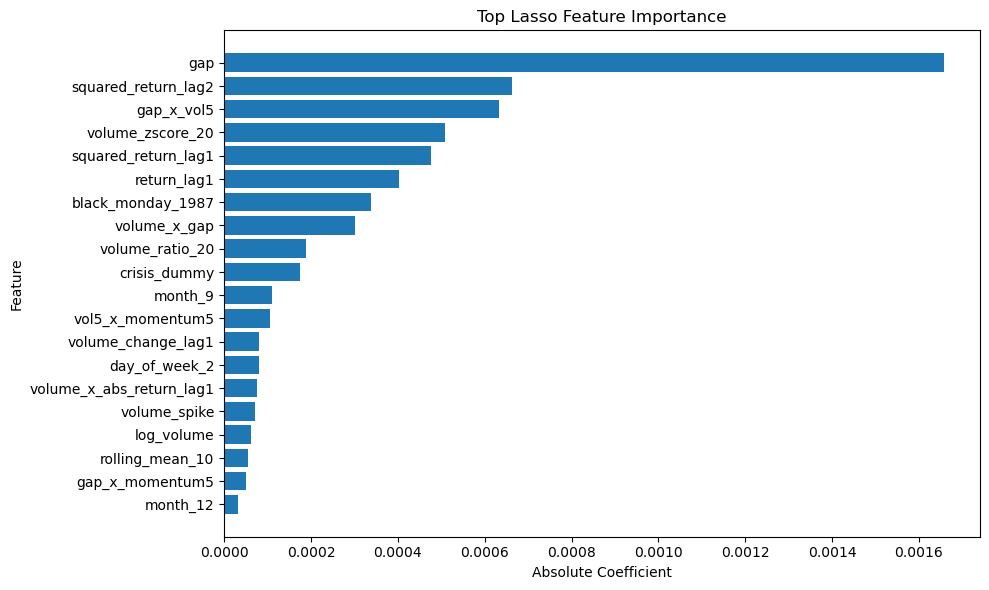

In [80]:
# ============================================================
# Plot top Lasso features
# ============================================================

top_n = 20
top_lasso = lasso_importance.head(top_n).sort_values("AbsCoefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_lasso["Feature"], top_lasso["AbsCoefficient"])
plt.title("Top Lasso Feature Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [81]:
# ============================================================
# Ridge coefficients
# ============================================================

ridge_pipeline = models["Ridge Regression"]
ridge_pipeline.fit(X_train, y_train)

ridge_coef = ridge_pipeline.named_steps["model"].coef_

ridge_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ridge_coef
})

ridge_importance["AbsCoefficient"] = ridge_importance["Coefficient"].abs()

ridge_importance = ridge_importance.sort_values(
    "AbsCoefficient",
    ascending=False
).reset_index(drop=True)

ridge_importance.head(20)

,Feature,Coefficient,AbsCoefficient
0,rolling_mean_5,-0.014297,0.014297
1,momentum_5,0.013584,0.013584
2,volume_x_abs_return_lag1,-0.002954,0.002954
3,momentum_10,-0.002782,0.002782
4,rolling_mean_10,0.002431,0.002431
5,squared_return_lag1,0.002214,0.002214
6,gap,0.001558,0.001558
7,squared_return_lag2,0.001270,0.001270
8,volume_ratio_20,0.001182,0.001182
9,abs_return_lag1,0.001109,0.001109


In [82]:
# ============================================================
# PCA explained variance
# ============================================================

pca_pipeline = models["PCA + Linear Regression"]
pca_pipeline.fit(X_train, y_train)

pca = pca_pipeline.named_steps["pca"]

print("Number of selected components:", pca.n_components_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})

pca_variance.head(20)

Number of selected components: 32
Total explained variance: 0.9507179718610865


,PC,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.142558,0.142558
1,PC2,0.094230,0.236788
2,PC3,0.060968,0.297755
3,PC4,0.051584,0.349339
4,PC5,0.038445,0.387784
5,PC6,0.031168,0.418952
6,PC7,0.029715,0.448667
7,PC8,0.026195,0.474861
8,PC9,0.025508,0.500369
9,PC10,0.025094,0.525463


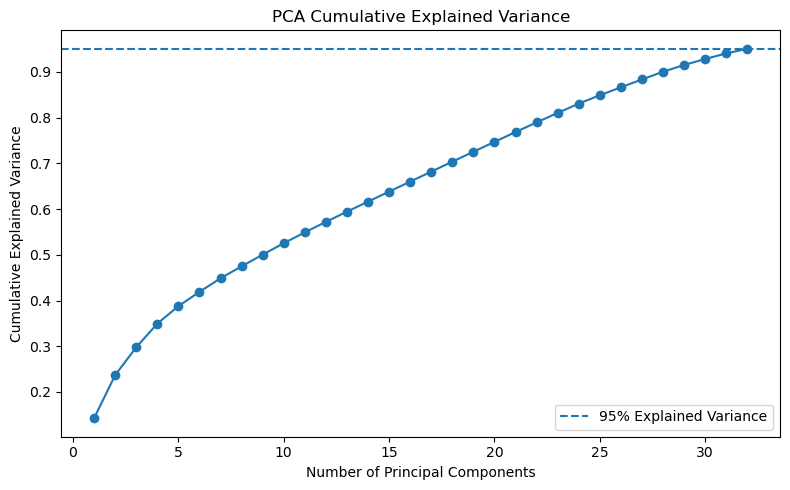

In [83]:
# ============================================================
# Plot PCA cumulative explained variance
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(y=0.95, linestyle="--", label="95% Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# Save predictions from all models
# ============================================================

predictions_df = pd.DataFrame({
    "Date": date_test.values,
    "Actual_Return": y_test.values
})

for model_name, model in models.items():
    predictions_df[model_name + "_Pred"] = model.predict(X_test)

predictions_df.head()

,Date,Actual_Return,Linear Regression_Pred,Ridge Regression_Pred,Lasso Regression_Pred,Polynomial Regression_Pred,kNN Regression_Pred,PCA + Linear Regression_Pred
0,2008-02-20,0.008341,-0.000119,-0.000051,-0.000731,-0.015440,0.000673,-0.001274
1,2008-02-21,-0.012867,0.001343,0.001337,0.001519,-0.008784,-0.000831,0.000584
2,2008-02-22,0.007881,0.000231,0.000219,0.000239,0.006271,-0.000117,-0.000293
3,2008-02-25,0.013813,-0.001098,-0.001014,-0.000217,-0.005446,0.001557,-0.000375
4,2008-02-26,0.006918,-0.000064,-0.000029,0.000508,-0.013835,-0.002901,0.000148


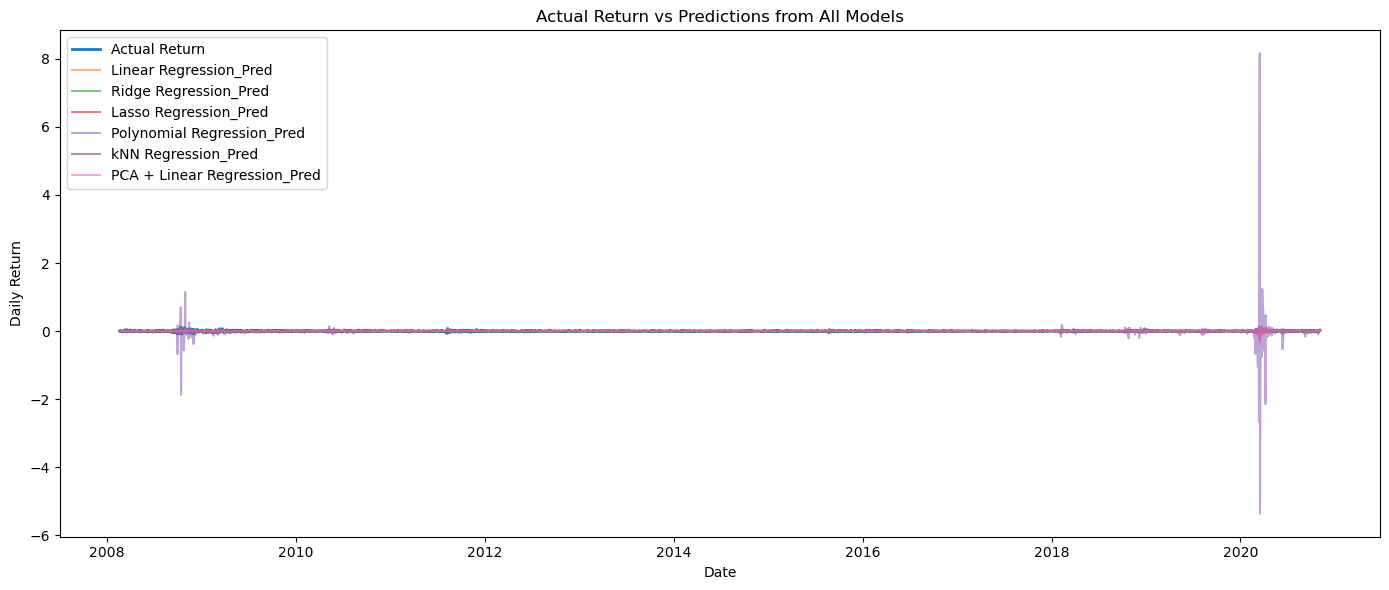

In [87]:
# 画 所有模型预测结果对比图
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(predictions_df["Date"], predictions_df["Actual_Return"], label="Actual Return", linewidth=2)

for col in predictions_df.columns:
    if col.endswith("_Pred"):
        plt.plot(predictions_df["Date"], predictions_df[col], label=col, alpha=0.6)

plt.title("Actual Return vs Predictions from All Models")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

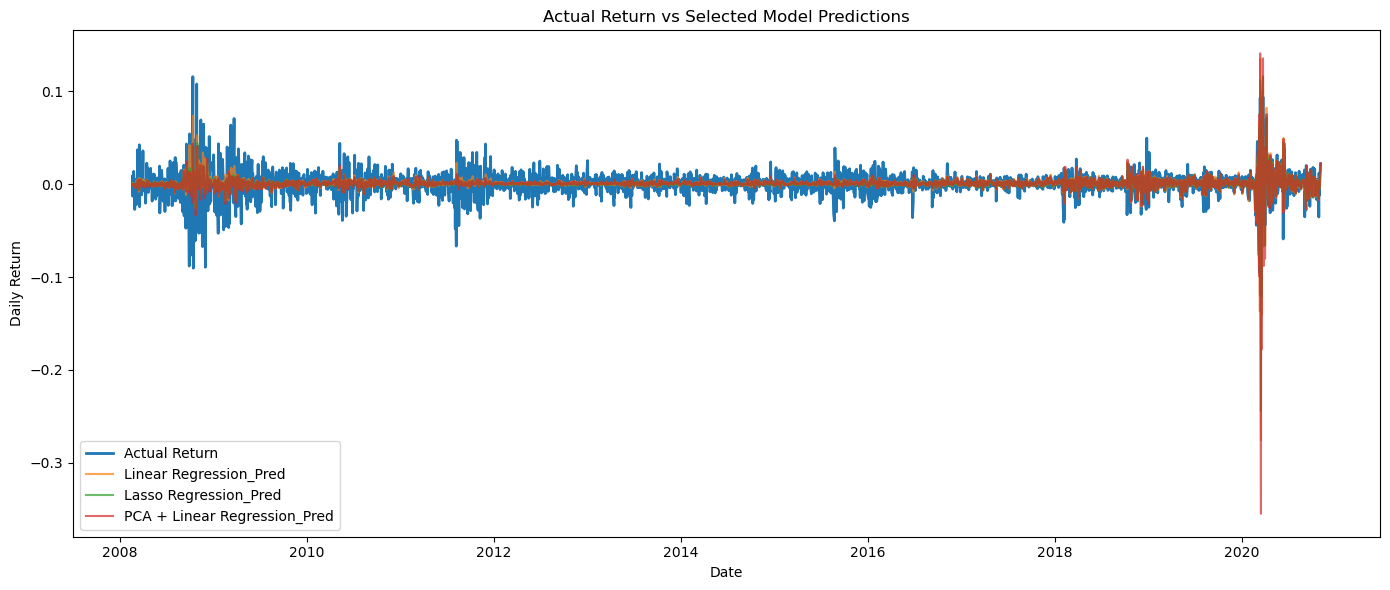

In [88]:
# 画 2~3 个代表模型
import matplotlib.pyplot as plt

selected_models = [
    "Linear Regression_Pred",
    "Lasso Regression_Pred",
    "PCA + Linear Regression_Pred"
]

plt.figure(figsize=(14, 6))
plt.plot(predictions_df["Date"], predictions_df["Actual_Return"], label="Actual Return", linewidth=2)

for col in selected_models:
    plt.plot(predictions_df["Date"], predictions_df[col], label=col, alpha=0.7)

plt.title("Actual Return vs Selected Model Predictions")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.tight_layout()
plt.show()

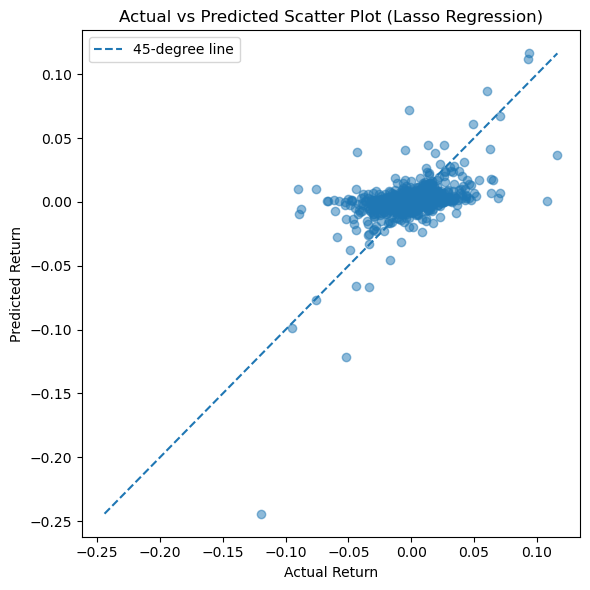

In [89]:
# 画 Actual vs Predicted 散点图
import matplotlib.pyplot as plt

best_pred_col = best_model_name + "_Pred"

plt.figure(figsize=(6, 6))
plt.scatter(predictions_df["Actual_Return"], predictions_df[best_pred_col], alpha=0.5)

min_val = min(predictions_df["Actual_Return"].min(), predictions_df[best_pred_col].min())
max_val = max(predictions_df["Actual_Return"].max(), predictions_df[best_pred_col].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="45-degree line")

plt.title(f"Actual vs Predicted Scatter Plot ({best_model_name})")
plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.legend()
plt.tight_layout()
plt.show()

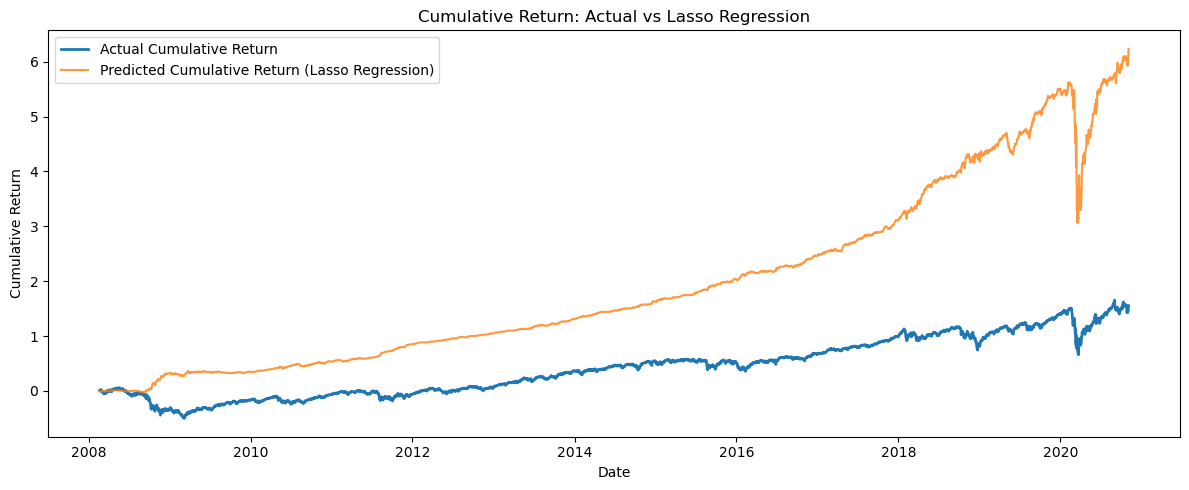

In [90]:
# 画 累计收益曲线
# ----------------

# 算cumulative return
plot_df = predictions_df.copy()

plot_df["Actual_CumReturn"] = (1 + plot_df["Actual_Return"]).cumprod() - 1

for col in plot_df.columns:
    if col.endswith("_Pred"):
        new_col = col.replace("_Pred", "_CumReturn")
        plot_df[new_col] = (1 + plot_df[col]).cumprod() - 1

# 画最佳模型累计收益
import matplotlib.pyplot as plt

best_cum_col = best_model_name + "_CumReturn"

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["Actual_CumReturn"], label="Actual Cumulative Return", linewidth=2)
plt.plot(plot_df["Date"], plot_df[best_cum_col], label=f"Predicted Cumulative Return ({best_model_name})", alpha=0.8)

plt.title(f"Cumulative Return: Actual vs {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

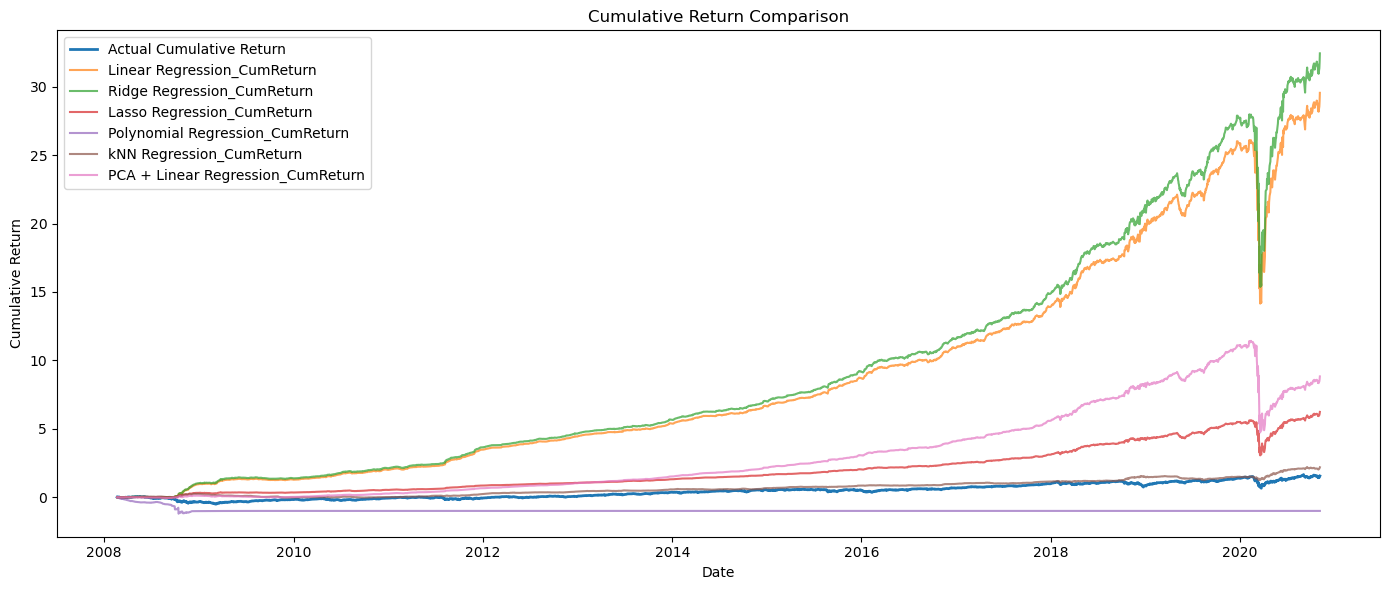

In [96]:
# 所有模型累计收益对比
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(plot_df["Date"], plot_df["Actual_CumReturn"], label="Actual Cumulative Return", linewidth=2)

for col in plot_df.columns:
    if col.endswith("_CumReturn") and col != "Actual_CumReturn":
        plt.plot(plot_df["Date"], plot_df[col], label=col, alpha=0.7)

plt.title("Cumulative Return Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.tight_layout()
plt.show()

In [97]:
# 画预测方向是否正确
direction_plot_df = predictions_df.copy()

direction_plot_df["Actual_Direction"] = (direction_plot_df["Actual_Return"] > 0).astype(int)

for col in direction_plot_df.columns:
    if col.endswith("_Pred"):
        direction_plot_df[col.replace("_Pred", "_Direction")] = (direction_plot_df[col] > 0).astype(int)

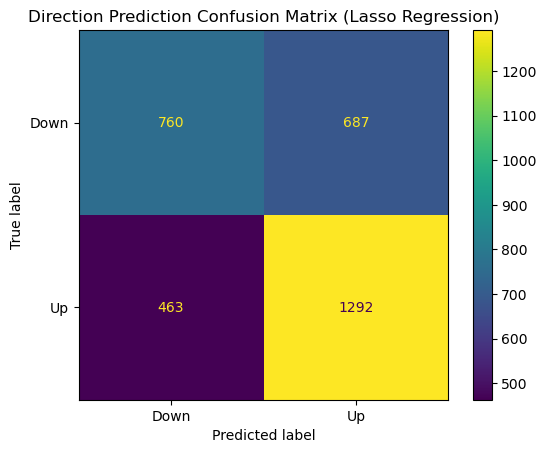

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

best_model_name = "Lasso Regression"
best_pred_col = best_model_name + "_Pred"

actual_direction = (predictions_df["Actual_Return"] > 0).astype(int)
pred_direction = (predictions_df[best_pred_col] > 0).astype(int)

cm = confusion_matrix(actual_direction, pred_direction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down", "Up"]
)

disp.plot()
plt.title(f"Direction Prediction Confusion Matrix ({best_model_name})")
plt.show()

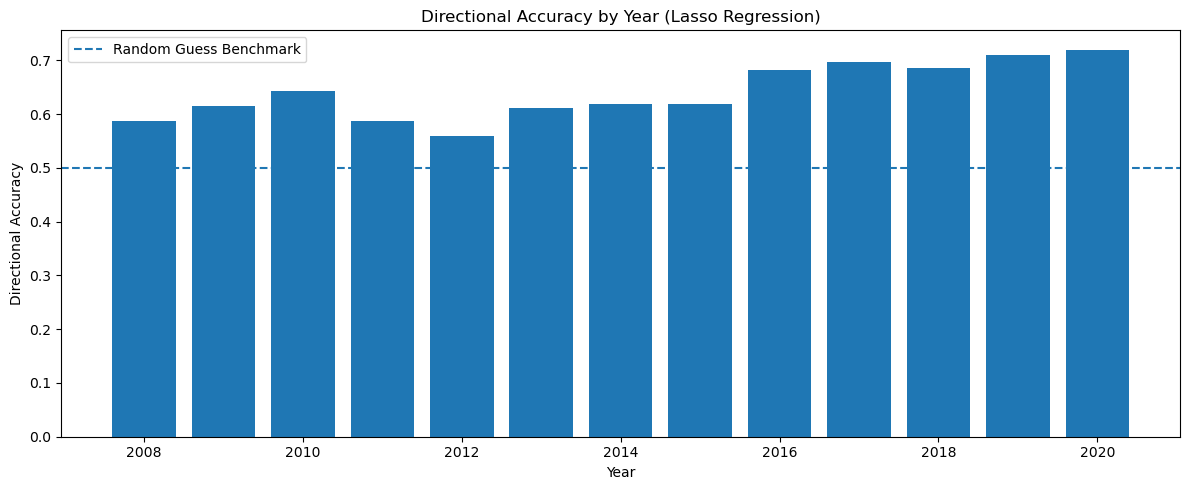

In [100]:
direction_df = predictions_df.copy()

direction_df["Year"] = pd.to_datetime(direction_df["Date"]).dt.year
direction_df["Actual_Direction"] = (direction_df["Actual_Return"] > 0).astype(int)
direction_df["Pred_Direction"] = (direction_df[best_pred_col] > 0).astype(int)
direction_df["Correct"] = (
    direction_df["Actual_Direction"] == direction_df["Pred_Direction"]
).astype(int)

yearly_acc = direction_df.groupby("Year")["Correct"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.bar(yearly_acc["Year"], yearly_acc["Correct"])
plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title(f"Directional Accuracy by Year ({best_model_name})")
plt.xlabel("Year")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

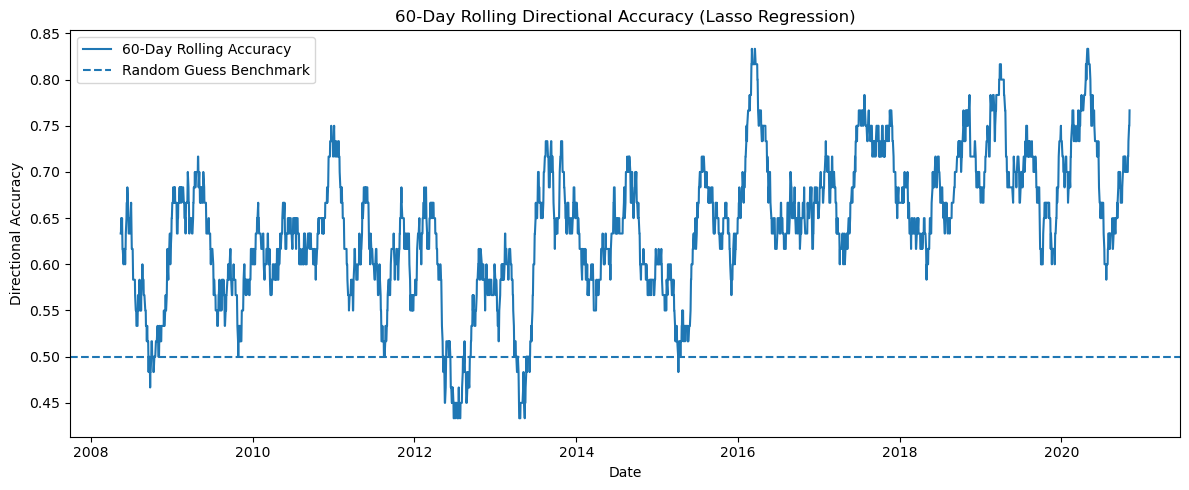

In [101]:
direction_df["Rolling_Accuracy_60D"] = direction_df["Correct"].rolling(60).mean()

plt.figure(figsize=(12, 5))
plt.plot(direction_df["Date"], direction_df["Rolling_Accuracy_60D"], label="60-Day Rolling Accuracy")
plt.axhline(0.5, linestyle="--", label="Random Guess Benchmark")
plt.title(f"60-Day Rolling Directional Accuracy ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Directional Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [102]:
direction_summary = pd.DataFrame({
    "Actual Up Ratio": [actual_direction.mean()],
    "Predicted Up Ratio": [pred_direction.mean()],
    "Directional Accuracy": [(actual_direction == pred_direction).mean()]
})

direction_summary

,Actual Up Ratio,Predicted Up Ratio,Directional Accuracy
0,0.548095,0.618051,0.640849


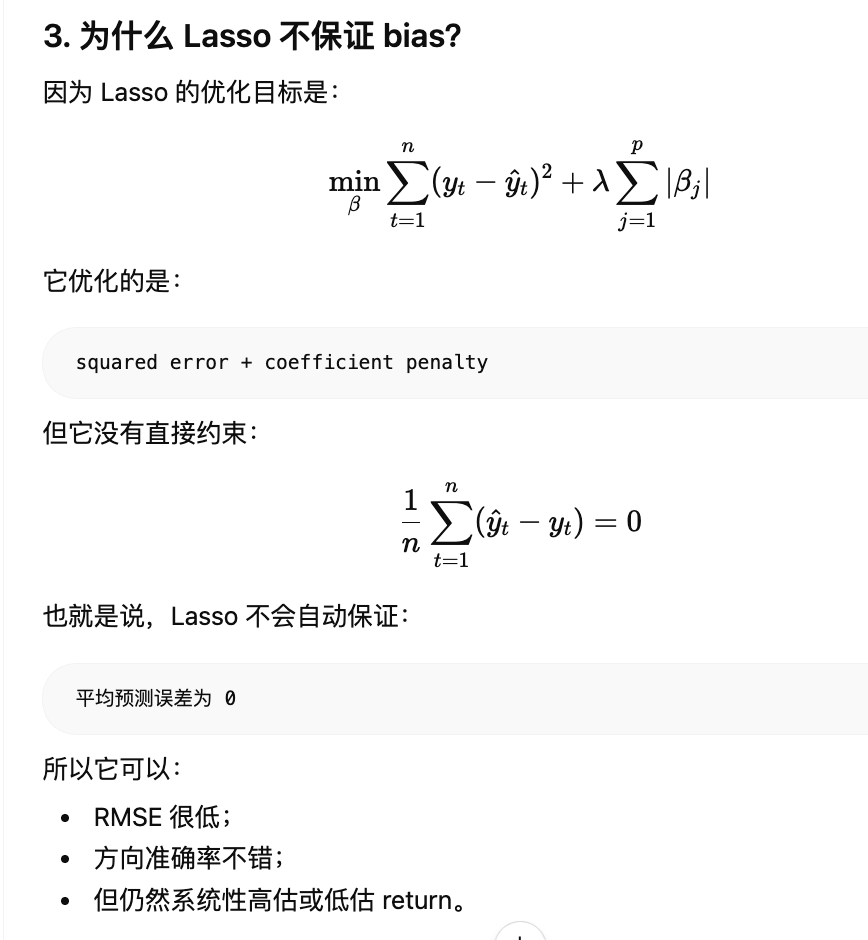

Target: continuous daily return

# Target: predict increase/decrease direction